# ***Import Libraries***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,GlobalAveragePooling2D
from tensorflow.keras.initializers import GlorotNormal
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow import keras
from tensorflow.keras.optimizers import Adam


from keras.models import load_model
from keras.preprocessing.image import load_img, img_to_array
from keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications import EfficientNetV2L

import random
import os
import warnings
warnings.filterwarnings('ignore')
print('compelete')

compelete


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

#!pip install kaggle

# Create a directory in your Google Drive to store the dataset
#!mkdir -p "/content/drive/My Drive/datasets/new-plant-diseases-dataset"

# Configure Kaggle API credentials
import os
os.environ['KAGGLE_CONFIG_DIR'] = "/content/drive/My Drive/datasets/.kaggle"

# Download the dataset directly to your Google Drive
#!kaggle datasets download -d vipoooool/new-plant-diseases-dataset -p "/content/drive/My Drive/datasets/new-plant-diseases-dataset"

# Unzip the downloaded dataset in your Google Drive
#!unzip "/content/drive/My Drive/datasets/new-plant-diseases-dataset/new-plant-diseases-dataset.zip" -d "/content/drive/My Drive/datasets/new-plant-diseases-dataset"

# ***Data understanding & Visualization***

In [ ]:
image_shape = (224,224)
batch_size = 64

#train_dir = "/content/drive/MyDrive/datasets/train_subset"
#valid_dir = "/content/drive/MyDrive/datasets/valid_subset"
#train_subset_dir = "/content/drive/MyDrive/datasets/train_subset"
#valid_subset_dir = "/content/drive/MyDrive/datasets/valid_subset"
train_dir = "/content/drive/MyDrive/train_sub"
valid_dir = "/content/drive/MyDrive/reduced_dataset/valid_sub"

# apply scaling only becouse data already augmented
train_datagen = ImageDataGenerator(rescale=1/255., validation_split=0.2)
test_datagen = ImageDataGenerator(rescale = 1/255.)

# load training data
print("Training Images:")
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=image_shape,
                                               batch_size=batch_size,
                                               class_mode='categorical',
                                               shuffle=True,
                                               subset='training')

# load validation data (20% of training data)
print("Validating Images:")
valid_data = train_datagen.flow_from_directory(valid_dir,
                                               target_size=image_shape,
                                               batch_size=batch_size,
                                               class_mode='categorical',
                                               shuffle=False,
                                               subset='validation')

# load test data (consider validation data as test data)
print('Test Images:')
test_data = test_datagen.flow_from_directory(valid_dir,
                                               target_size=image_shape,
                                               batch_size=batch_size,
                                               class_mode='categorical',
                                               shuffle=False)


Training Images:
Found 6328 images belonging to 37 classes.
Validating Images:
Found 159 images belonging to 37 classes.
Test Images:
Found 823 images belonging to 37 classes.


In [ ]:
# show how data store
images, labels = next(iter(train_data))
print(f'shape of image is : {images[0].shape}')
print(f'label  \n{labels[0]}')

shape of image is : (224, 224, 3)
label  
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


In [ ]:
# show all diseases in dataset
diseases = list(train_data.class_indices.keys()) # Get class names from the class_indices attribute
print(diseases)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Y

In [ ]:
import os

# Extract class names from the folder names
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

print("Class names:", class_names)

import json

# Get the current working directory
current_directory = os.getcwd()  # Assign current working directory to current_directory

# Construct the file path
file_path = os.path.join(current_directory, 'class_names.json')

with open('/content/drive/MyDrive/kaggle/working/class_names.json', 'w') as f:
    json.dump(class_names, f)

Class names: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Toma

In [ ]:
# identify uniqe plant in dataset
plants = []
NumberOfDiseases = 0
for plant in diseases:
    if plant.split('___')[0] not in plants:
        plants.append(plant.split('___')[0])
print(f'number of different plants is :{len(plants)}')
print(plants)

number of different plants is :13
['Apple', 'Cherry_(including_sour)', 'Corn_(maize)', 'Grape', 'Orange', 'Peach', 'Pepper,_bell', 'Potato', 'Raspberry', 'Soybean', 'Squash', 'Strawberry', 'Tomato']


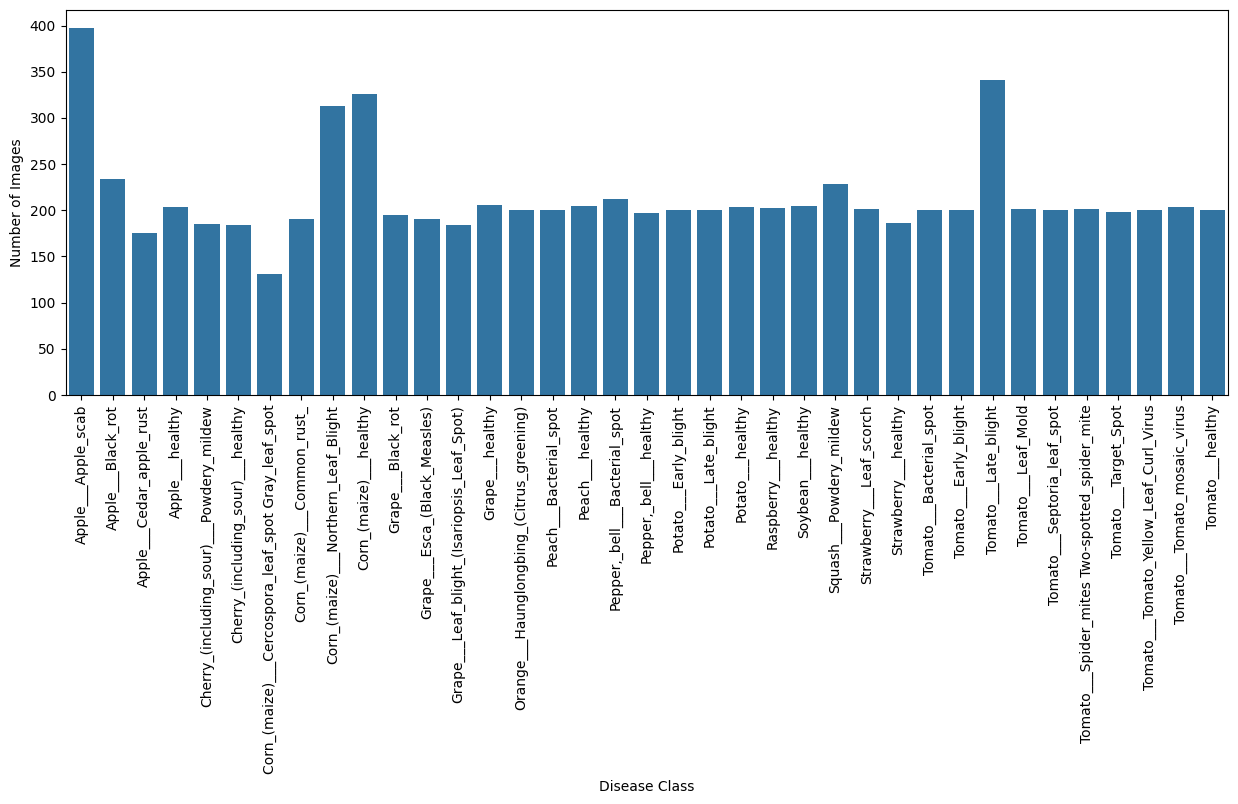

In [ ]:
# show number of each class
dic = {}
for Class in diseases:
    dic[Class] = len(os.listdir(train_dir + '/' + Class))

df = pd.DataFrame(list(dic.items()), columns=["Disease Class", "Number of Images"])

# df = df.sort_values(by="Number of Images", ascending=False)

plt.figure(figsize=(15,5))
sns.barplot(data=df ,x='Disease Class' ,y= 'Number of Images' )
plt.xticks(rotation=90)
plt.show()

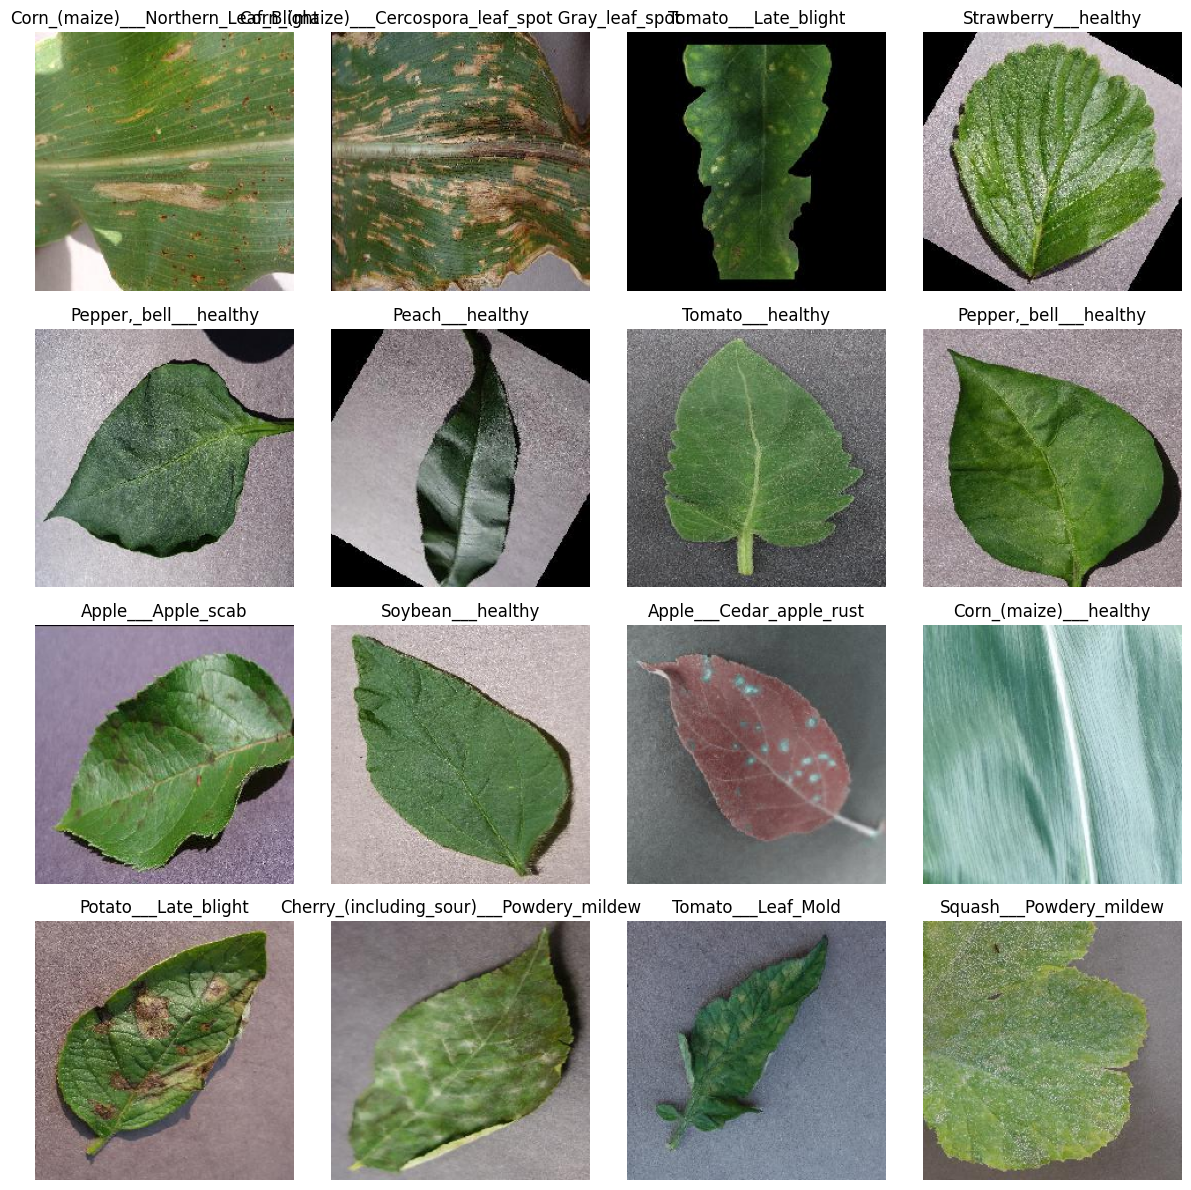

In [ ]:
import random
# select a specific batch
images, labels = next(iter(train_data))

# select 16 image by random
indices = random.sample(range(len(images)), 16)
selected_images = images[indices]
selected_labels = labels[indices]

class_names = list(train_data.class_indices.keys())

# plotting
plt.figure(figsize=(12, 12))
for i in range(16):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(selected_images[i])
    plt.title(class_names[np.argmax(selected_labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()


# ***Modeling***

# ***CNN Model***

In [ ]:
# Model Architecture
model = Sequential()

model.add(Conv2D(32,(3,3),activation = 'elu',input_shape=(224,224,3), kernel_initializer=GlorotNormal()))
model.add(Conv2D(32, (3,3), activation='elu', kernel_initializer=GlorotNormal()))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='elu', kernel_initializer=GlorotNormal()))
model.add(Conv2D(64, (3,3), activation='elu', kernel_initializer=GlorotNormal()))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='elu', kernel_initializer=GlorotNormal()))
model.add(Conv2D(128, (3,3), activation='elu', kernel_initializer=GlorotNormal()))
model.add(MaxPooling2D(2,2))

# model.add(Flatten())
model.add(GlobalAveragePooling2D())

model.add(Dense(256, activation='elu', kernel_initializer=GlorotNormal()))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(128, activation='elu', kernel_initializer=GlorotNormal()))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64, activation='elu', kernel_initializer=GlorotNormal()))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(37, activation='softmax'))

model.compile(loss='categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 220, 220, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 110, 110, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 108, 108, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 106, 106, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 53, 53, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 51, 51, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 49, 49, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 24, 24, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 365,381 (1.39 MB)

 Trainable params: 364,485 (1.39 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# train the model
model_checkpoint = ModelCheckpoint('/content/drive/MyDrive/kaggle/working/cnn_model.weights.h5', monitor='val_accuracy',save_weights_only=True, save_best_only=False, mode='max', verbose=1)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, verbose=1, mode='max', restore_best_weights=True)

history = model.fit(train_data,
                    validation_data=valid_data,
                    epochs=10,
                    batch_size=64,
                    callbacks=[model_checkpoint, early_stopping])

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - accuracy: 0.1264 - loss: 3.3410 
Epoch 1: saving model to /content/drive/MyDrive/kaggle/working/cnn_model.weights.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 2426s 23s/step - accuracy: 0.1270 - loss: 3.3373 - val_accuracy: 0.1635 - val_loss: 3.1011
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - accuracy: 0.3200 - loss: 2.3312 
Epoch 2: saving model to /content/drive/MyDrive/kaggle/working/cnn_model.weights.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 2220s 22s/step - accuracy: 0.3203 - loss: 2.3301 - val_accuracy: 0.2579 - val_loss: 3.3977
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - accuracy: 0.4464 - loss: 1.9145 
Epoch 3: saving model to /content/drive/MyDrive/kaggle/working/cnn_model.weights.h5
99/99 ━━━━━━━━━━━━━━━━━━━━ 2226s 22s/step - accuracy: 0.4465 - loss: 1.9139 - val_accuracy: 0.2453 - val_loss: 3.6008
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 22s/step - accuracy: 0.5081 - loss: 1.6732 
Epoch 4: saving model to /content/drive/MyDrive/kaggle

In [ ]:
# save model to use later
# model.save('/content/drive/MyDrive/kaggle/working/my_cnn_model79.keras')


In [ ]:
#  model.load_weights("/content/drive/MyDrive/kaggle/working/cnn_model.h5")  # Replace with the path to the desired checkpoint


In [ ]:
# show accuracy on test data (model evaluation)
best_model = load_model('/content/drive/MyDrive/kaggle/working/my_cnn_model79.keras')

test_loss, test_accuracy = best_model.evaluate(test_data)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 299s 24s/step - accuracy: 0.7952 - loss: 0.5991
Test Loss: 0.6050
Test Accuracy: 0.8019


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def predict_labels_and_display(model_path, test_data, num_samples=4):
    """
    Predicts labels for a random sample of test data and displays the images with predicted and true labels.

    Args:
        model_path (str): Path to the saved Keras model.
        test_data (ImageDataGenerator): Test data generator.
        num_samples (int): Number of samples to display. Defaults to 16.
    """
    # Load the trained model
    model = load_model(model_path)

    # Get a random sample of images and labels from the test data
    images, true_labels = next(iter(test_data))
    indices = np.random.choice(len(images), num_samples, replace=False)
    selected_images = images[indices]
    selected_true_labels = true_labels[indices]

    # Predict labels for the selected images
    predicted_labels = model.predict(selected_images)
    predicted_classes = np.argmax(predicted_labels, axis=1)
    true_classes = np.argmax(selected_true_labels, axis=1)

    # Get class names
    class_names = list(test_data.class_indices.keys())

    # Display the images with predicted and true labels
    plt.figure(figsize=(12, 12))
    for i in range(num_samples):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(selected_images[i])
        predicted_label = class_names[predicted_classes[i]]
        true_label = class_names[true_classes[i]]
        title = f"Predicted: {predicted_label}\nTrue: {true_label}"
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


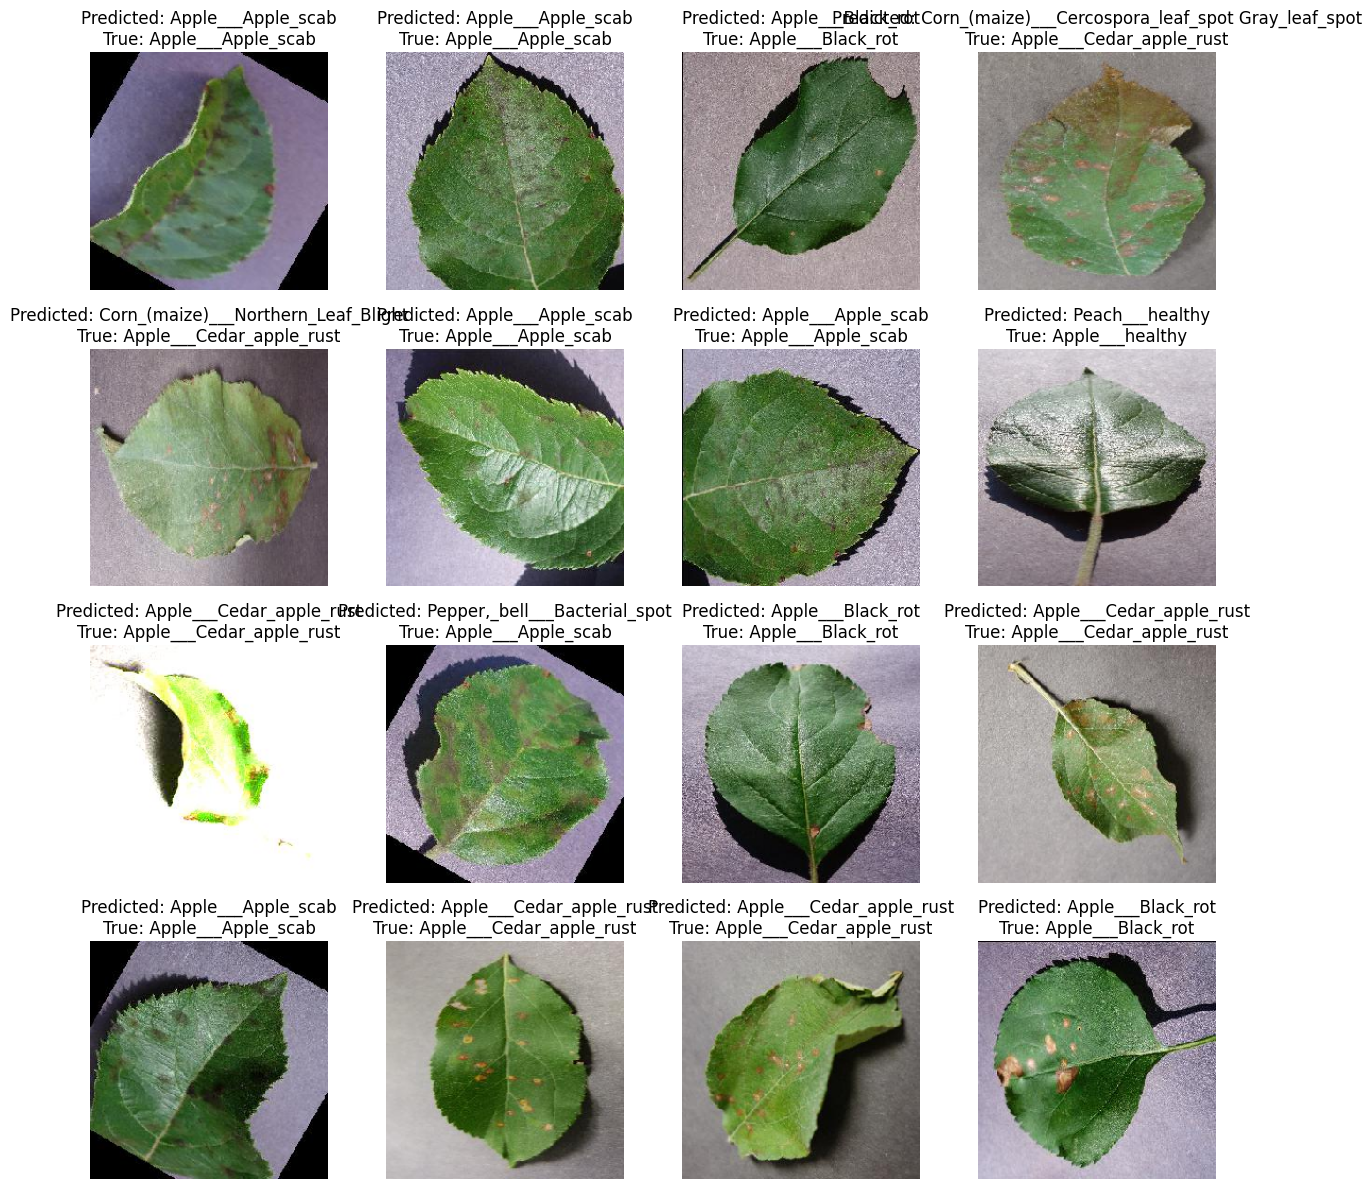

In [ ]:
# show random sample of prediction of model on test data
predict_labels_and_display('/content/drive/MyDrive/kaggle/working/my_cnn_model79.keras',test_data)

In [ ]:
# Function to plot learning curves
def plot_learning_curves(history):
    plt.figure(figsize=(12, 4))

    # Accuracy curve
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()

    # Loss curve
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

In [ ]:
# show learning curves
# plot_learning_curves(history)

# ***Classification report***

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

def evaluate_model(model_path, test_data, model_name):
    # load model
    model = tf.keras.models.load_model(model_path)

    # predict
    y_pred = model.predict(test_data)
    y_pred_classes = y_pred.argmax(axis=1)

    # get true classes
    y_true = test_data.classes

    class_labels = list(test_data.class_indices.keys())

    accuracy = accuracy_score(y_true, y_pred_classes)

    report = classification_report(y_true, y_pred_classes, target_names=class_labels, output_dict=True)

    df_report = pd.DataFrame(report).transpose()

    df_report.loc['accuracy'] = [accuracy, None, None, None]

    df_report['model'] = model_name

    return df_report

cnn_model_path = '/content/drive/MyDrive/kaggle/working/my_cnn_model79.keras'

cnn_report = evaluate_model(cnn_model_path, test_data, 'CNN')

reports = pd.concat([cnn_report])

reports = reports.reset_index().rename(columns={'index': 'metric'})

reports


13/13 ━━━━━━━━━━━━━━━━━━━━ 131s 10s/step


,metric,precision,recall,f1-score,support,model
0,Apple___Apple_scab,0.681818,0.750000,0.714286,20.0,CNN
1,Apple___Black_rot,0.714286,1.000000,0.833333,20.0,CNN
2,Apple___Cedar_apple_rust,0.823529,0.777778,0.800000,18.0,CNN
3,Apple___healthy,0.916667,0.500000,0.647059,22.0,CNN
4,Cherry_(including_sour)___Powdery_mildew,0.888889,0.800000,0.842105,20.0,CNN
5,Cherry_(including_sour)___healthy,1.000000,0.750000,0.857143,20.0,CNN
6,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.857143,0.652174,0.740741,46.0,CNN
7,Corn_(maize)___Common_rust_,0.947368,0.818182,0.878049,22.0,CNN
8,Corn_(maize)___Northern_Leaf_Blight,0.745455,0.976190,0.845361,42.0,CNN
9,Corn_(maize)___healthy,0.978723,1.000000,0.989247,46.0,CNN


In [ ]:
pd.set_option('display.max_rows', 123)

reports

,metric,precision,recall,f1-score,support,model
0,Apple___Apple_scab,0.681818,0.750000,0.714286,20.0,CNN
1,Apple___Black_rot,0.714286,1.000000,0.833333,20.0,CNN
2,Apple___Cedar_apple_rust,0.823529,0.777778,0.800000,18.0,CNN
3,Apple___healthy,0.916667,0.500000,0.647059,22.0,CNN
4,Cherry_(including_sour)___Powdery_mildew,0.888889,0.800000,0.842105,20.0,CNN
5,Cherry_(including_sour)___healthy,1.000000,0.750000,0.857143,20.0,CNN
6,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.857143,0.652174,0.740741,46.0,CNN
7,Corn_(maize)___Common_rust_,0.947368,0.818182,0.878049,22.0,CNN
8,Corn_(maize)___Northern_Leaf_Blight,0.745455,0.976190,0.845361,42.0,CNN
9,Corn_(maize)___healthy,0.978723,1.000000,0.989247,46.0,CNN


In [ ]:
 x =reports[reports['metric'] == 'macro avg']
 x

,metric,precision,recall,f1-score,support,model
38,macro avg,0.823906,0.791754,0.794129,823.0,CNN


### Loading the user Image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step


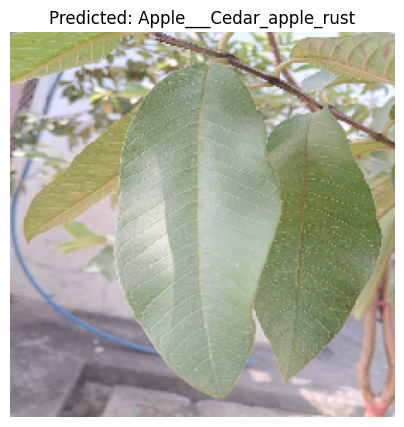

Image: leaf01.jpg
Predicted Class: Apple___Cedar_apple_rust
Class Probabilities: [[8.4465108e-04 4.5849389e-04 3.8284135e-01 3.8003904e-04 3.8235714e-03
  4.4465609e-04 2.3377359e-01 5.2983570e-03 3.1277350e-01 3.9824823e-04
  2.9237531e-04 2.0745338e-04 1.3484023e-04 2.1453124e-02 1.9097786e-03
  6.6114930e-03 1.4646599e-04 8.9548405e-05 2.5661209e-05 2.9938004e-03
  1.1522481e-03 3.1265823e-05 5.7462821e-06 6.9440226e-04 2.8638798e-03
  5.1218452e-04 8.2789074e-06 1.3400974e-02 4.8675577e-04 4.4743069e-03
  7.3443131e-05 2.1500819e-04 8.8475308e-06 5.4637221e-06 4.8205158e-05
  7.4887489e-06 1.1105220e-03]]
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


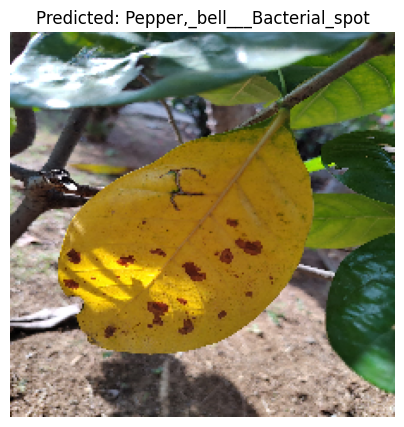

Image: leaf02.jpg
Predicted Class: Pepper,_bell___Bacterial_spot
Class Probabilities: [[6.6469089e-05 4.7234995e-03 2.5769544e-04 3.1677759e-05 1.5081907e-05
  2.2551776e-05 6.3963496e-05 6.5656804e-04 1.4957846e-05 6.8526706e-06
  2.6103996e-03 1.2751268e-01 4.7285995e-03 4.3437405e-05 9.2913938e-04
  9.8320179e-02 2.3910622e-04 7.0207292e-01 7.6330645e-04 4.1589673e-04
  1.3261741e-05 7.3531114e-06 1.1197943e-03 2.8697928e-06 1.3824653e-06
  1.6226326e-03 8.9737921e-05 2.9616058e-04 1.7287247e-02 1.5938474e-03
  1.3740028e-03 2.2502817e-02 1.4751732e-04 5.3355343e-05 9.4130496e-03
  9.7006792e-04 9.9518138e-06]]
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


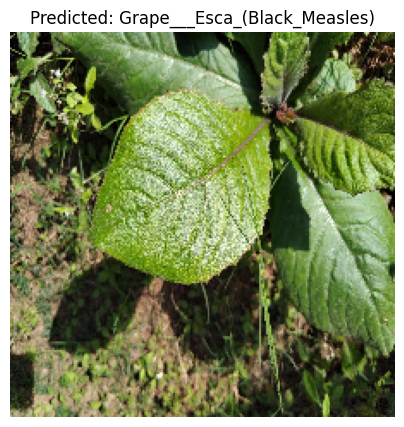

Image: leaf03.jpg
Predicted Class: Grape___Esca_(Black_Measles)
Class Probabilities: [[4.23548445e-05 3.63821571e-04 1.30518421e-03 3.20989260e-04
  3.67421337e-04 5.83993642e-05 1.49469050e-02 3.12407523e-01
  3.91804351e-04 2.89574102e-03 5.63266361e-03 4.54550266e-01
  8.46045837e-02 5.93929843e-04 3.06771362e-05 1.18560063e-04
  9.52478731e-04 3.55708525e-02 4.43380373e-03 3.28521654e-02
  1.00449426e-03 4.82912175e-04 4.58097225e-03 1.12619906e-04
  1.61268210e-04 7.81418011e-03 7.14812952e-04 4.20997443e-04
  2.03299951e-02 1.44105987e-03 4.79888782e-04 1.77828973e-04
  1.37668033e-03 1.84059481e-03 3.10981111e-03 9.57575452e-04
  2.55410466e-03]]
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


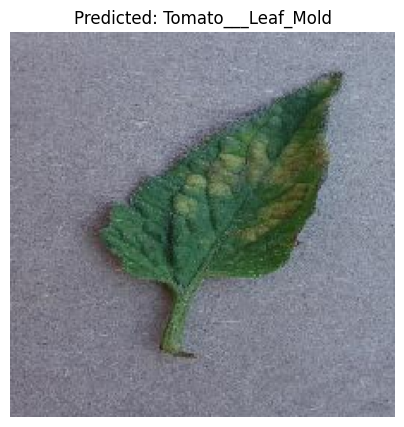

Image: Corn_mold.JPG
Predicted Class: Tomato___Leaf_Mold
Class Probabilities: [[3.5524374e-04 1.6355925e-05 8.7259948e-05 7.1234140e-04 1.4609940e-03
  4.4539993e-06 3.5405687e-06 3.2739847e-06 2.0940874e-06 1.8083334e-06
  7.0135263e-07 2.3586230e-05 7.5024457e-07 6.2530768e-07 2.0394220e-05
  1.1418470e-02 1.0364627e-04 2.0193256e-05 9.2851369e-06 2.2863131e-05
  3.3947927e-06 9.9242743e-07 6.9609209e-06 4.1765024e-06 1.3499125e-06
  3.5431526e-06 6.1690807e-06 1.1537519e-04 4.8336276e-04 3.2645487e-03
  9.7816396e-01 1.9238242e-03 1.3698686e-04 4.6667654e-05 1.2833773e-03
  1.2973552e-04 1.5770897e-04]]
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


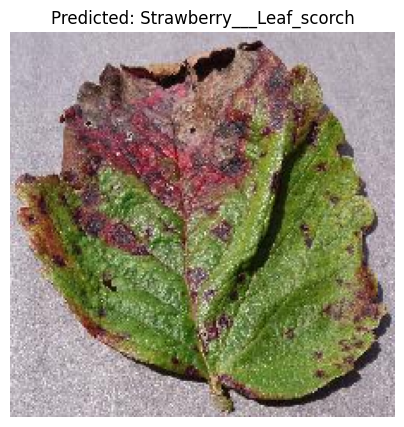

Image: scorch.JPG
Predicted Class: Strawberry___Leaf_scorch
Class Probabilities: [[1.6761263e-08 1.1648264e-06 7.6248476e-08 1.1378746e-08 2.1655684e-07
  2.1856431e-06 9.7092277e-07 4.4059828e-07 9.1689126e-06 3.0143760e-06
  4.0212384e-04 2.4586006e-03 2.0317130e-03 1.4940663e-07 2.4981750e-07
  3.0227820e-06 7.4325939e-08 3.4348633e-07 1.1971056e-07 3.7681980e-07
  1.4786229e-05 1.3313553e-05 4.4826735e-03 1.4778348e-07 7.8360072e-06
  9.9050903e-01 1.5121501e-06 1.0497978e-06 1.2947976e-08 3.5160268e-09
  1.1140403e-06 3.5403340e-07 5.8821838e-06 3.2142964e-06 1.0254867e-05
  2.4004814e-05 1.0704394e-05]]
--------------------------------------------------


In [ ]:
import os
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt  # Import matplotlib for image display

# Load your trained model
# Replace with the actual path to your model
best_model = load_model('/content/drive/MyDrive/kaggle/working/my_cnn_model79.keras')

# Define the path to the folder containing images
folder_path = "/content/drive/MyDrive/custom_image"

# Get the class names from the test dataset
# Replace 'test_data' with your actual ImageDataGenerator object if needed
class_names = list(test_data.class_indices.keys())  # Example: ['cat', 'dog', 'bird']

# Function to preprocess and predict a single image
def predict_image(image_path, model, class_names, target_size=(224, 224)):
    # Load and preprocess the image
    img = load_img(image_path, target_size=target_size)
    img_array = img_to_array(img)  # Convert the image to a NumPy array
    img_array = img_array / 255.0  # Apply rescaling
    img_array = np.expand_dims(img_array, axis=0)  # Add a batch dimension

    # Predict the class
    prediction = model.predict(img_array)
    predicted_class_index = np.argmax(prediction)  # Find the index of the highest probability
    predicted_class_name = class_names[predicted_class_index]  # Get the class name

    return predicted_class_name, prediction, img

# Iterate through all images in the folder and predict
for image_name in os.listdir(folder_path):
    image_path = os.path.join(folder_path, image_name)

    if image_name.lower().endswith(('.png', '.jpg', '.jpeg')):  # Check for valid image extensions
        try:
            # Get predictions and the preprocessed image
            predicted_class_name, prediction, img = predict_image(image_path, best_model, class_names)

            # Display the image and predictions
            plt.figure(figsize=(5, 5))  # Set the figure size
            plt.imshow(img)  # Show the image
            plt.axis('off')  # Remove axis for a cleaner look
            plt.title(f"Predicted: {predicted_class_name}")  # Add the predicted class as title
            plt.show()

            # Print additional details
            print(f"Image: {image_name}")
            print(f"Predicted Class: {predicted_class_name}")
            print(f"Class Probabilities: {prediction}")
            print("-" * 50)
        except Exception as e:
            print(f"Error processing image {image_name}: {e}")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D, Input, Average
from tensorflow.keras.initializers import GlorotNormal
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam
from keras.models import load_model
from keras.preprocessing.image import load_img, img_to_array
from keras.applications import VGG16, ResNet50, InceptionV3
import random
import os
import warnings
warnings.filterwarnings('ignore')

# Setup directories for data
# train_dir = "/content/drive/MyDrive/datasets/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
# valid_dir = "/content/drive/MyDrive/datasets/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

image_shape = (224, 224)
batch_size = 64

# Image Data Generator with rescaling
# train_datagen = ImageDataGenerator(rescale=1/255., validation_split=0.2)
# test_datagen = ImageDataGenerator(rescale=1/255.)

# Load training and validation data
#train_data = train_datagen.flow_from_directory(train_subset_dir, target_size=image_shape, batch_size=batch_size, class_mode='categorical', shuffle=True, subset='training')
#valid_data = train_datagen.flow_from_directory(valid_subset_dir, target_size=image_shape, batch_size=batch_size, class_mode='categorical', shuffle=False, subset='validation')

# Load the pre-trained models (VGG16, ResNet50, InceptionV3)
input_shape = (224, 224, 3)
num_classes = 38  # Assuming 38 classes

# VGG16 model
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
x_vgg = Flatten()(vgg_base.output)
x_vgg = Dense(256, activation='relu')(x_vgg)
vgg_output = Dense(num_classes, activation='softmax')(x_vgg)
vgg_model = Model(inputs=vgg_base.input, outputs=vgg_output)

# ResNet50 model
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
x_resnet = GlobalAveragePooling2D()(resnet_base.output)
x_resnet = Dense(256, activation='relu')(x_resnet)
resnet_output = Dense(num_classes, activation='softmax')(x_resnet)
resnet_model = Model(inputs=resnet_base.input, outputs=resnet_output)

# InceptionV3 model
inception_base = InceptionV3(weights='imagenet', include_top=False, input_shape=input_shape)
x_inception = GlobalAveragePooling2D()(inception_base.output)
x_inception = Dense(256, activation='relu')(x_inception)
inception_output = Dense(num_classes, activation='softmax')(x_inception)
inception_model = Model(inputs=inception_base.input, outputs=inception_output)

# Ensemble model
ensemble_input = Input(shape=input_shape)
vgg_prediction = vgg_model(ensemble_input)
resnet_prediction = resnet_model(ensemble_input)
inception_prediction = inception_model(ensemble_input)

# Average predictions from all models
ensemble_output = Average()([vgg_prediction, resnet_prediction, inception_prediction])
ensemble_model = Model(inputs=ensemble_input, outputs=ensemble_output)

# Compile the ensemble model
ensemble_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of the ensemble model
ensemble_model.summary()

# Set up callbacks
model_checkpoint = ModelCheckpoint('/content/drive/MyDrive/ensemble_model.keras', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=3, verbose=1, mode='max', restore_best_weights=True)

# Saving model weights after each iteration

# Train the ensemble model
history = ensemble_model.fit(train_data, validation_data=valid_data, epochs=10, batch_size=batch_size, callbacks=[model_checkpoint, early_stopping])

# Save the trained ensemble model
ensemble_model.save('/content/drive/MyDrive/ensemble_model.h5')

# Plot learning curves
def plot_learning_curves(history):
    plt.figure(figsize=(12, 4))

    # Accuracy curve
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()

    # Loss curve
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

# Plot the learning curves
plot_learning_curves(history)

# Evaluate the model
best_model = load_model('/content/drive/MyDrive/ensemble_model.h5')
test_loss, test_accuracy = best_model.evaluate(valid_data)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional (Functional)   │ (None, 38)             │     21,147,238 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional_1 (Functional) │ (None, 38)             │     24,122,022 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ functional_2 (Functional) │ (None, 38)             │     22,337,094 │ input_layer_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ average (Average)         │ (None, 38)             │              0 │ functional[0][0],      │
│                           │                        │                │ functional_1[0][0],    │
│                           │                        │                │ functional_2[0][0]     │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 67,606,354 (257.90 MB)

 Trainable params: 67,518,802 (257.56 MB)

 Non-trainable params: 87,552 (342.00 KB)

Epoch 1/2
